This is a fraud detection system designed to predict whether a credit card transaction is fraudulent or not.     
The data I shall be using is the FraudTest dataset I obtained from Kaggle.

My model of choice is the RandomForestClassifier from sklearn.

First, let's import it.

In [2]:
import pandas as pd
#First look at the data
df = pd.read_csv("fraudTest.csv", index_col="trans_num")

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

df.rename(columns= {df.columns[0]: "ID"} , inplace=True)

df

,ID,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
trans_num,,,,,,,,,,,,,,,,,,,,,
2da90c7d74bd46a0caf3777415b3ebd3,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,1371816865,33.986391,-81.200714,0
324cc204407e99f51b0d6ca0055005e7,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,1371816873,39.450498,-109.960431,0
c81755dbbbea9d5c77f094348a7579be,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,1371816893,40.495810,-74.196111,0
2159175b9efe66dc301f149d3d5abf8c,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,1371816915,28.812398,-80.883061,0
57ff021bd3f328f8738bb535c302a31b,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9b1f753c79894c9f4b71f04581835ada,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,63453,40.4931,-91.8912,519,Town planner,1966-02-13,1388534347,39.946837,-91.333331,0
2090647dac2c89a1d86c514c427f5b91,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,77566,29.0393,-95.4401,28739,Futures trader,1999-12-27,1388534349,29.661049,-96.186633,0
6c5b7c8add471975aa0fec023b2e8408,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,99323,46.1966,-118.9017,3684,Musician,1981-11-29,1388534355,46.658340,-119.715054,0


In [3]:
print(df.info())

print(df.describe())

print(df.shape)

print(df.isna().sum())

<class 'pandas.DataFrame'>
Index: 555719 entries, 2da90c7d74bd46a0caf3777415b3ebd3 to 1765bb45b3aa3224b4cdcb6e7a96cee3
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64


In this case, there are no missing vlaues, meaning no need for data cleaning and so we move on. Now, let's take a look at the fraud values. 0 for Non-Fraud, 1 for Fraud.

In [17]:
df['is_fraud'] = df['is_fraud'].astype(int)
print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize = True))

is_fraud
0    553574
1      2145
Name: count, dtype: int64
is_fraud
0    0.99614
1    0.00386
Name: proportion, dtype: float64


In this case, we are dealing with highly imbalanced data, with fraud cases taking up only 0.386% of cases. On a pie chart it looks like this:

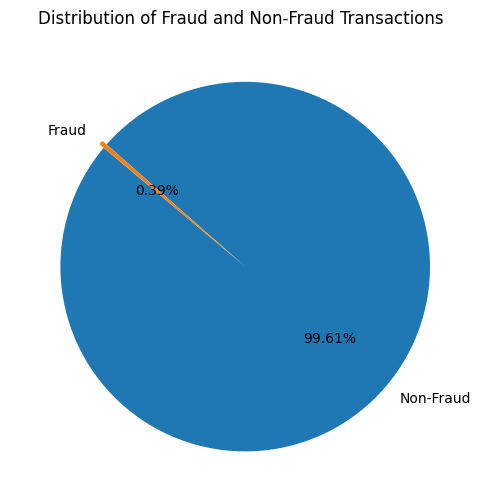

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
labels = ['Non-Fraud', 'Fraud']
sizes = df['is_fraud'].value_counts()
plt.pie(sizes, labels=labels, autopct='%1.2f%%', explode=(0.03, 0), startangle=140)
plt.title('Distribution of Fraud and Non-Fraud Transactions')
plt.show()

The next step is feature engineering.

Firstly, I will create Frequency columns for both merchants and categories

Then, I want to change the trans_date_trans_time column and dob columns into dates. 

Also, I will create new columns of DayOfWeek, Hour of transaction and IsWeekend from trans_date_trans_time  .

To finish, I will count the number of transactions a user does and the avg amount spent on each of them.

In [5]:
df['Merchant_Frequency'] = df['merchant'].map(df['merchant'].value_counts())
df['Category_Frequency'] = df['category'].map(df['category'].value_counts())

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])


df['Hour'] = df['trans_date_trans_time'].dt.hour
df['Day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['Is_weekend'] = df['Day_of_week'].isin([5,6]).astype(int)

df = df.drop('trans_date_trans_time', axis=1)

df['Transactions_per_user'] = df.groupby('cc_num')['amt'].transform('count')
df['Avg_amount_per_user'] = df.groupby('cc_num')['amt'].transform('mean')

df.head(3)

,ID,cc_num,merchant,category,amt,first,last,gender,street,city,...,merch_lat,merch_long,is_fraud,Merchant_Frequency,Category_Frequency,Hour,Day_of_week,Is_weekend,Transactions_per_user,Avg_amount_per_user
trans_num,,,,,,,,,,,,,,,,,,,,,
2da90c7d74bd46a0caf3777415b3ebd3,0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.986391,-81.200714,0,736,39327,12,6,1,640,61.893062
324cc204407e99f51b0d6ca0055005e7,1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,39.450498,-109.960431,0,785,39327,12,6,1,837,53.596523
c81755dbbbea9d5c77f094348a7579be,2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.495810,-74.196111,0,755,36674,12,6,1,1073,83.053812


Now, I will select all the columns I believe I will need for the model (In this case, they are all numerical.)


In [7]:
X = df.select_dtypes(include=['number'])
X = X.drop(columns = ["ID", "is_fraud"])

y = df["is_fraud"]

print(X.shape)

(555719, 16)


Next, splitting the data into training and testing data. I will stratify it to make sure I have the same proprtion of fraud cases in the train and test datas.

In [8]:
from sklearn.model_selection import train_test_split

# Splitting the testing and training data 80% - 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=10)


Remember we are dealing with imbalanced data. A model cannot be trained to its best accuracy with such data. So what can be done here is to oversample the data. I will do so using SMOTE.


I also added a StratifiedKFold to perform stratified sampling and produce folds with a representative ratio of each class of y.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)
smote = SMOTE(k_neighbors=3, random_state=10)

for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    X_train_scaled, y_train_scaled = smote.fit_resample(X_fold_train, y_fold_train)

Little visualization of what the Fraud and Non-Fraud values look like after the SMOTE:

([<matplotlib.patches.Wedge at 0x1ff30d4ca50>,
 [Text(-1.1299999999999957, -9.878774140420898e-08, 'Non-Fraud'),
  Text(1.0999999999999832, 1.9233011600819372e-07, 'Fraud')],
 [Text(-0.6299999999999977, -5.5076351402346585e-08, '50.0%'),
  Text(0.5999999999999908, 1.0490733600446929e-07, '50.0%')])

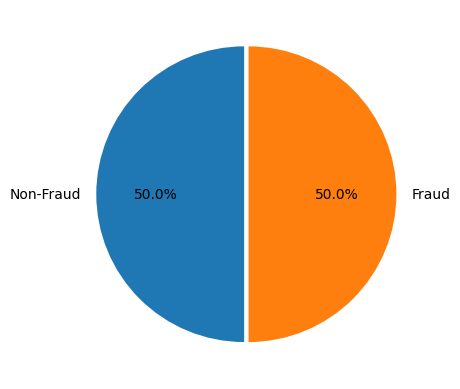

In [10]:
class_counts = y_train_scaled.value_counts()
plt.pie(class_counts.values, labels=['Non-Fraud', 'Fraud'], autopct='%1.1f%%', explode=(0.03, 0), startangle=90)

Up next, hyperparameter tuning. 
Here I'm supposed to run a Cross-Validator (CV), but it took a very long time to complete. So what I did here was to get the best parameters after running a RandomizedSearchCV and input them into my model.

In [11]:
# I tried running the RandomizedSearchCV, but it took 99 mins to complete. So I just took the best hyperparams it gave me.
'''param_grid = {
    'n_estimators': [10, 20, 50, 100],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}

rand_search = RandomizedSearchCV(estimator=classifier, param_distributions=param_grid, cv=5, n_jobs=-1, scoring = 'f1', n_iter=30, n_jobs=-1)

rand_search.fit(X_train_scaled, y_train_scaled)

print(f"Best parameters: {rand_search.best_params_}")
print(f"Best score: {rand_search.best_score_}")
'''

'''Best parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}
Best score: 0.9990197300982956'''

"Best parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}\nBest score: 0.9990197300982956"

The fun part: Fitting the my model with the train-scaled data I obtained from the SMOTE, and use the hyperparameters gotten from the SearchCV above.

In [12]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=50, n_jobs=-1,
                                    max_depth=None, min_samples_split=2, 
                                    criterion= 'gini', min_samples_leaf=1, 
                                    class_weight = 'balanced', random_state=10)

classifier.fit(X_train_scaled, y_train_scaled)


,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Below I will used the fitted model to predict the test data based on what it has learnt from the scaled training data, and its probability of being correct.

In [13]:
y_predicted = classifier.predict(X_test)

y_probability = classifier.predict_proba(X_test)[:,1]

print(y_predicted, y_probability)
print(len(y_predicted), "                        ",len(y_probability))

[0 0 0 ... 0 0 0] [0. 0. 0. ... 0. 0. 0.]
111144                          111144


Metrics:

I need them to see how well my model fares with unseen data, Whether it overfits or not. Or another unforseen issue.

I will use the Classification Report, Confusion Matrix, ROC-AUC score and Average Precision score here.

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score

print("Classification report: ")
print()
print(classification_report(y_test, y_predicted))
print()

print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_predicted))
print()

print()
print(f"ROC_AUC Score: {roc_auc_score(y_test, y_probability)}")
print()

print()
print("Precision-Recall Curve:")
precision, recall, thresholds = precision_recall_curve(y_test, y_probability)
for p, r, t in zip(precision, recall, thresholds):
    print(f"Threshold: {t:.2f}, Precision: {p:.2f}, Recall: {r:.2f}")

print()
print(f"Average Precision Score: {average_precision_score(y_test, y_probability)}")

Classification report: 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.78      0.78      0.78       429

    accuracy                           1.00    111144
   macro avg       0.89      0.89      0.89    111144
weighted avg       1.00      1.00      1.00    111144



Confusion Matrix:
[[110622     93]
 [    95    334]]


ROC_AUC Score: 0.9885439283352846


Precision-Recall Curve:
Threshold: 0.00, Precision: 0.00, Recall: 1.00
Threshold: 0.02, Precision: 0.03, Recall: 0.99
Threshold: 0.04, Precision: 0.07, Recall: 0.96
Threshold: 0.06, Precision: 0.11, Recall: 0.95
Threshold: 0.08, Precision: 0.14, Recall: 0.94
Threshold: 0.10, Precision: 0.18, Recall: 0.93
Threshold: 0.12, Precision: 0.21, Recall: 0.93
Threshold: 0.14, Precision: 0.24, Recall: 0.93
Threshold: 0.16, Precision: 0.28, Recall: 0.92
Threshold: 0.18, Precision: 0.31, Recall: 0.92
Threshold: 0.20, Precision: 0.34, Recall: 0.91
Threshold: 0.2

After that, threshold tuning to determine the best threshold to run the model at. I'll add a graph to show how the precisions and recalls vary as well as the optimal threshold.

Best Threshold: 0.5600
Max F1-Score: 0.7966


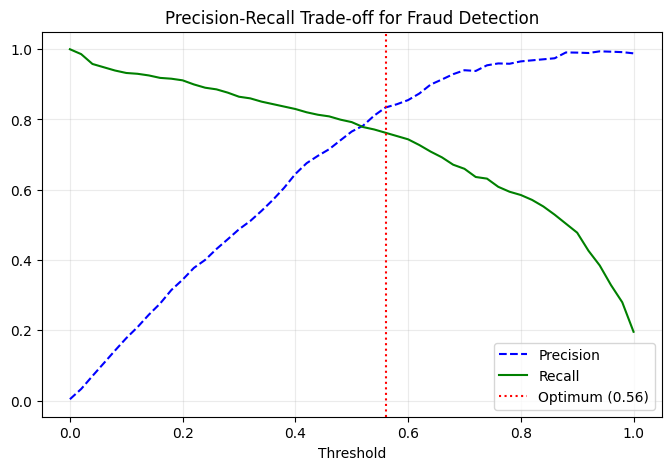


Classification report with optimized threshold: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.83      0.76      0.80       429

    accuracy                           1.00    111144
   macro avg       0.92      0.88      0.90    111144
weighted avg       1.00      1.00      1.00    111144

[[110650     65]
 [   102    327]]
ROC_AUC Score with optimized threshold: 0.9885439283352846


In [ ]:
import numpy as np

def tune_fraud_threshold(y_predicted, y_probs):
    
    precisions, recalls, thresholds = precision_recall_curve(y_predicted, y_probs)
    
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    print(f"Best Threshold: {best_threshold:.4f}")
    print(f"Max F1-Score: {best_f1:.4f}")
    
    
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.axvline(best_threshold, color="red", linestyle=":", label=f"Optimum ({best_threshold:.2f})")
    plt.xlabel("Threshold")
    plt.title("Precision-Recall Trade-off for Fraud Detection")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()
    
    return best_threshold


opt_threshold = tune_fraud_threshold(y_test, y_probability)
y_pred = (y_probability >= opt_threshold).astype(int)
print()
print("Classification report with optimized threshold: ")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"ROC_AUC Score with optimized threshold: {roc_auc_score(y_test, y_probability)}")

Finally, I decided to show how important each of the features of X were to the model. 

And I added another pie chart to emphasize on it.

Index(['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'Merchant_Frequency', 'Category_Frequency',
       'Hour', 'Day_of_week', 'Is_weekend', 'Transactions_per_user',
       'Avg_amount_per_user'],
      dtype='str')

[0.02264931 0.52030364 0.01557367 0.01677309 0.01587256 0.02150191
 0.05143313 0.01467931 0.0160502  0.02310604 0.08496918 0.04148644
 0.01181416 0.00248791 0.05822283 0.08307662]


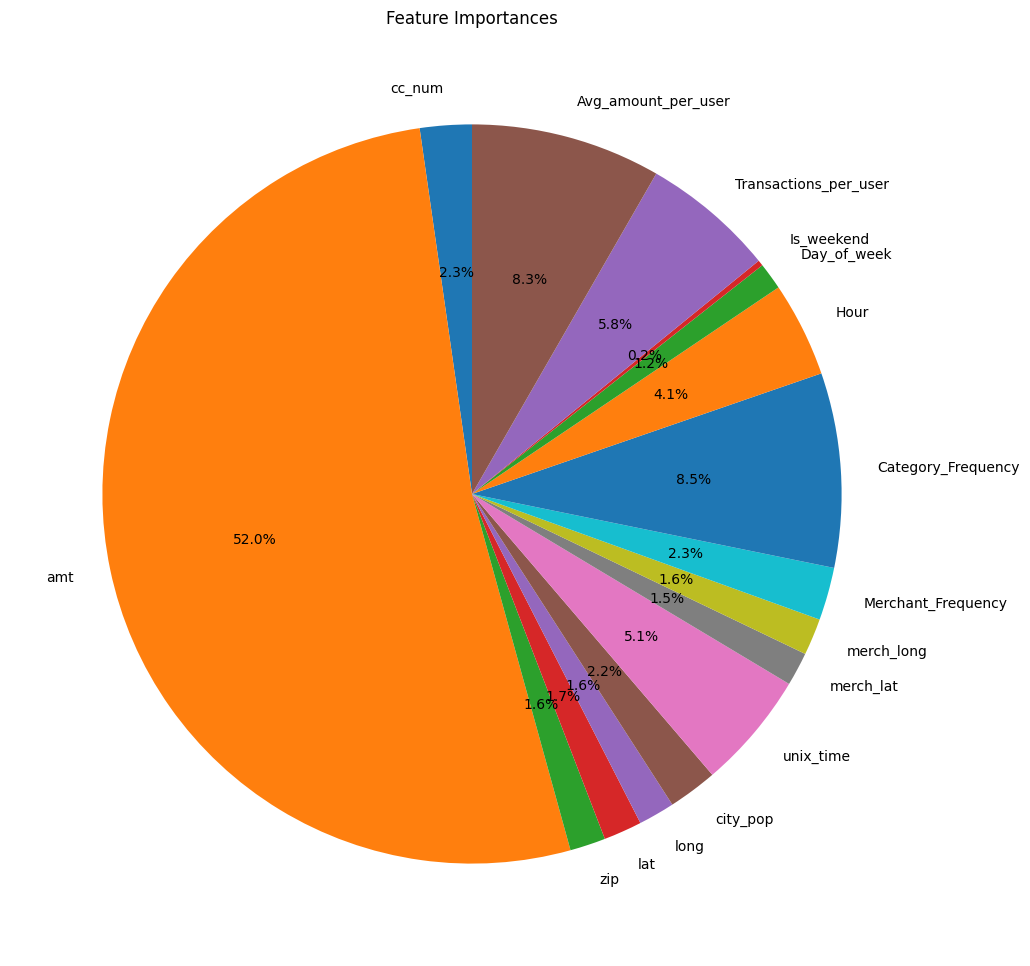

In [21]:
print(X_train_scaled.columns)
print()
print(classifier.feature_importances_)

plt.figure(figsize=(12,12))
plt.pie(classifier.feature_importances_, labels=X.columns, autopct='%1.1f%%', startangle=90)
plt.title('Feature Importances')
plt.show()


This concludes my Fraud Detection project. Thank you all.